## Jupyter Notebook for Analyzing and visualyzing Prescription csv


In [ ]:
"""
Created on Mon Nov 3 2025

@author: Laura Rueda
"""
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
filename = "data/deid_rx_order.csv"

try:
    df = pd.read_csv(filename)
except Exception as e:
    print(f"Error reading '{filename}': {e}")
else:
    print("Columns:", list(df.columns))
    


Columns: ['AIM_GROUP', 'PATIENT_ID', 'ENCOUNTER_ID', 'RX_CODE', 'RX_NAME', 'RX_EPIC_NAME', 'ROUTE', 'DOSE', 'FREQUENCY', 'Shifted_date']


In [5]:
#First 10 rows
display(df.head(10))

,AIM_GROUP,PATIENT_ID,ENCOUNTER_ID,RX_CODE,RX_NAME,RX_EPIC_NAME,ROUTE,DOSE,FREQUENCY,Shifted_date
0,1_NoD,268709,2168233,RXNORM:1735013,fentanyl,NaN,IV PUSH,50 mcg,ONE TIME ONLY,2016-04-08 16:27:00
1,1_NoD,268709,2168233,RXNORM:1735013,fentanyl,NaN,IV PUSH,50 mcg,ONE TIME ONLY,2016-04-08 16:30:00
2,1_NoD,268709,2168233,RXNORM:1807628,"NaCl 0.9% 1,000 mL",NaN,IV,NaN,NaN,2016-04-08 13:06:00
3,1_NoD,268709,2168233,RXNORM:6960,midazolam,NaN,IV PUSH,0.5 mg,ONE TIME ONLY,2016-04-08 16:27:00
4,1_NoD,268709,2168233,RXNORM:6960,midazolam,NaN,IV PUSH,0.5 mg,ONE TIME ONLY,2016-04-08 16:28:00
5,1_NoD,268709,2168233,RXNORM:856999,acetaminophen-hydrocodone,NaN,PO,NaN,ONE TIME ONLY,2016-04-08 18:51:00
6,1_NoD,268709,1662238,RXNORM:2582,clindamycin,NaN,NaN,NaN,NaN,2017-08-10 13:29:00
7,1_NoD,268709,1662238,RXNORM:723,amoxicillin,NaN,NaN,NaN,NaN,2017-08-10 13:29:00
8,1_NoD,268709,1494652,RXNORM:1115005,docusate,NaN,PO,100 mg,BID,2014-01-01 23:00:00
9,1_NoD,268709,1494652,RXNORM:1116927,dexamethasone,NaN,IV PUSH,4 mg,Q6H,2014-01-02 18:35:00


In [6]:
# Last 10 rows
display(df.tail(10))

,AIM_GROUP,PATIENT_ID,ENCOUNTER_ID,RX_CODE,RX_NAME,RX_EPIC_NAME,ROUTE,DOSE,FREQUENCY,Shifted_date
20436691,2_Type2,24613,5690860,RXNORM:9863,DOBUTamine 1000 mg + NaCl 0.9% 250 mL,SODIUM CHLORIDE 0.9 % IV SOLN,*Unspecified,0.9 %,Continuous PRN,2019-09-08 17:37:00
20436692,2_Type2,24613,1108718,RXNORM:5956,iohexol,IOHEXOL 300 MG/ML IJ SOLN,Intravenous,300 MG/ML,Once in imaging,2020-01-27 11:43:00
20436693,2_Type2,24613,1108718,NaN,IOHEXOL 350 MG/ML (26 ML) IV SOLN FOR ORAL USE,IOHEXOL 350 MG/ML (26 ML) IV SOLN FOR ORAL USE,Oral,350 MG/ML,Once in imaging,2020-01-27 11:43:00
20436694,2_Type2,171914,3001515,RXNORM:161,acetaminophen,NaN,PO,"1,000 mg",ONE TIME ONLY,2019-09-08 13:48:00
20436695,2_Type2,171914,3001515,RXNORM:5640,ibuprofen,NaN,PO,600 mg,ONE TIME ONLY,2019-09-08 13:48:00
20436696,2_Type2,171914,2335888,NaN,BLOOD PRESSURE MONITOR MISC,BLOOD PRESSURE MONITOR MISC,Does not apply,NaN,Daily,2019-09-20 00:00:00
20436697,2_Type2,171914,662967,RXNORM:18993,benzonatate,BENZONATATE 100 MG PO CAPS,Oral,100 MG,3 times daily PRN,2019-09-15 00:00:00
20436698,2_Type2,171914,662967,RXNORM:197397,benzonatate,BENZONATATE 100 MG PO CAPS,Oral,100 MG,3 times daily PRN,2019-09-15 00:00:00
20436699,2_Type2,171914,1319780,RXNORM:6809,metFORMIN,METFORMIN HCL 500 MG PO TABS,Oral,500 MG,2 times daily with meals,2019-10-04 00:00:00
20436700,2_Type2,171914,1319780,RXNORM:861007,metFORMIN,METFORMIN HCL 500 MG PO TABS,Oral,500 MG,2 times daily with meals,2019-10-04 00:00:00


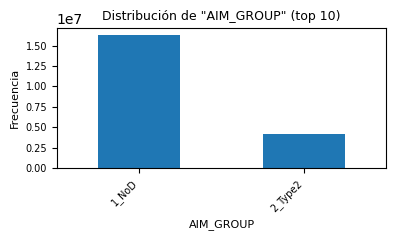

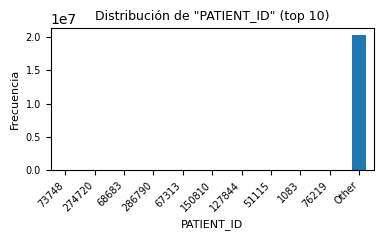

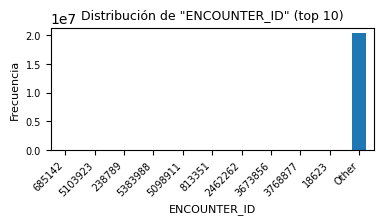

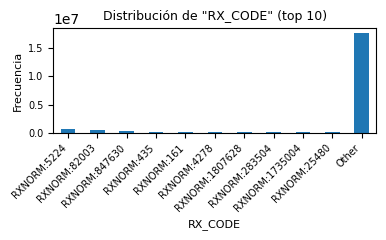

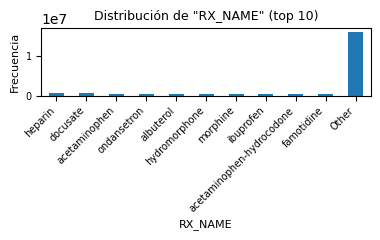

C:\Users\rueda\AppData\Local\Temp\ipykernel_24472\659954061.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


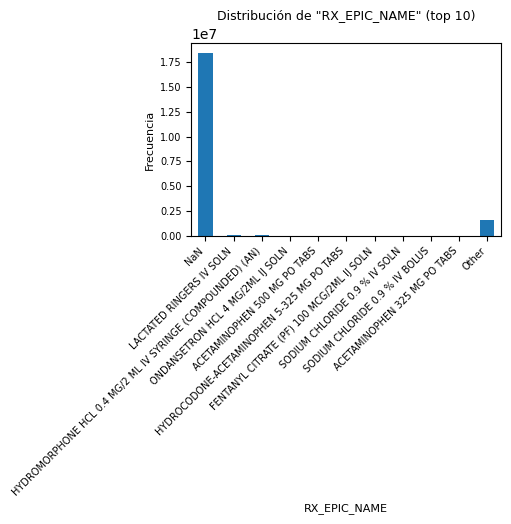

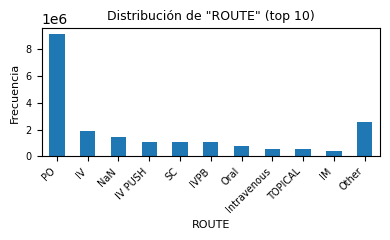

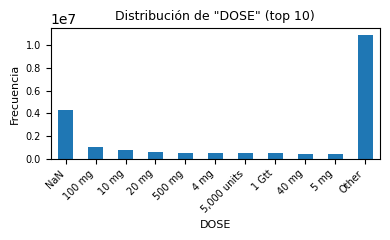

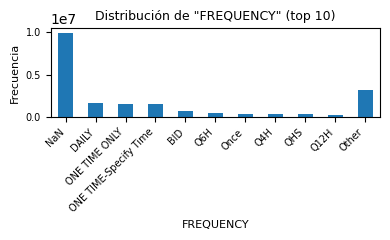

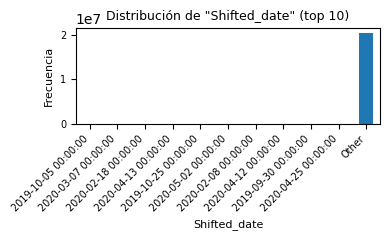

In [13]:
small_figsize = (4, 2.5)  

def plot_column_distribution(df, col, top_n=10, chart='bar', include_na=True):
    s = df[col].fillna('NaN') if include_na else df[col].dropna()
    vc = s.value_counts()
    if vc.empty:
        return
    if len(vc) > top_n:
        top = vc.iloc[:top_n].copy()
        top['Other'] = vc.iloc[top_n:].sum()
    else:
        top = vc
    fig, ax = plt.subplots(figsize=small_figsize, dpi=100)
    if chart == 'bar':
        top.plot.bar(ax=ax, color='tab:blue')
        ax.set_ylabel('Frecuencia', fontsize=8)
        ax.set_xlabel(col, fontsize=8)
        ax.set_title(f'Distribución de "{col}" (top {top_n})', fontsize=9)
        plt.xticks(rotation=45, ha='right', fontsize=7)
        ax.tick_params(axis='y', labelsize=7)
    else:
        top.plot.pie(ax=ax, autopct='%1.1f%%', startangle=90, counterclock=False,
                     textprops={'fontsize':7})
        ax.set_ylabel('')
        ax.set_title(f'Porcentaje de "{col}" (top {top_n})', fontsize=9)
    plt.tight_layout()
    plt.show()

# Generar un gráfico más pequeño por cada columna del dataframe
for column in df.columns:
    plot_column_distribution(df, column, top_n=top_n, chart=chart_type)

In [9]:
# Resumen compacto de valores por columna (lista de top_n valores con conteos)
max_items = top_n  # usa la variable ya definida en el notebook

rows = []
for col in df.columns:
    # contar valores (tratando NaN como 'NaN' para que aparezca en los top)
    vc = df[col].fillna('NaN').value_counts()
    unique_count = vc.shape[0]
    dtype = df[col].dtype
    
    # preparar lista de top items con su conteo
    top_items = []
    for val, cnt in vc.iloc[:max_items].items():
        top_items.append(f"{val} ({cnt})")
    if len(vc) > max_items:
        other_cnt = int(vc.iloc[max_items:].sum())
        top_items.append(f"Other ({other_cnt})")
    
    rows.append({
        "column": col,
        "dtype": str(dtype),
        "unique_count": int(unique_count),
        "top_values": "; ".join(top_items)
    })

summary_df = pd.DataFrame(rows)
# Mostrar una tabla compacta
pd.options.display.max_colwidth = 200
display(summary_df)

,column,dtype,unique_count,top_values
0,AIM_GROUP,object,2,1_NoD (16292902); 2_Type2 (4143799)
1,PATIENT_ID,int64,248812,73748 (26456); 274720 (22761); 68683 (20966); 286790 (20292); 67313 (20030); 150810 (20024); 127844 (19953); 51115 (19917); 1083 (17881); 76219 (17173); Other (20231248)
2,ENCOUNTER_ID,int64,2029786,685142 (17847); 5103923 (12713); 238789 (11923); 5383988 (11446); 5098911 (11277); 813351 (10426); 2462262 (9604); 3673856 (8970); 3768877 (8831); 18623 (8800); Other (20324864)
3,RX_CODE,object,13291,RXNORM:5224 (641579); RXNORM:82003 (515907); RXNORM:847630 (323604); RXNORM:435 (215283); RXNORM:161 (212854); RXNORM:4278 (211986); RXNORM:1807628 (208704); RXNORM:283504 (194618); RXNORM:1735004...
4,RX_NAME,object,8503,heparin (729983); docusate (676415); acetaminophen (421849); ondansetron (401339); albuterol (361891); hydromorphone (353119); morphine (333791); ibuprofen (332642); acetaminophen-hydrocodone (305...
5,RX_EPIC_NAME,object,7075,NaN (18442250); LACTATED RINGERS IV SOLN (73100); HYDROMORPHONE HCL 0.4 MG/2 ML IV SYRINGE (COMPOUNDED) (AN) (54880); ONDANSETRON HCL 4 MG/2ML IJ SOLN (43212); ACETAMINOPHEN 500 MG PO TABS (33130)...
6,ROUTE,object,184,PO (9068782); IV (1885636); NaN (1412639); IV PUSH (1110220); SC (1055161); IVPB (1040156); Oral (800664); Intravenous (553316); TOPICAL (538827); IM (375300); Other (2596000)
7,DOSE,object,32426,"NaN (4318435); 100 mg (1000647); 10 mg (760510); 20 mg (624914); 500 mg (542370); 4 mg (475251); 5,000 units (457771); 1 Gtt (457050); 40 mg (435822); 5 mg (406221); Other (10957710)"
8,FREQUENCY,object,210,NaN (9907033); DAILY (1638195); ONE TIME ONLY (1550740); ONE TIME-Specify Time (1533001); BID (789366); Q6H (445805); Once (368028); Q4H (343589); QHS (329026); Q12H (289999); Other (3241919)
9,Shifted_date,object,4123679,2019-10-05 00:00:00 (2524); 2020-03-07 00:00:00 (2475); 2020-02-18 00:00:00 (2462); 2020-04-13 00:00:00 (2386); 2019-10-25 00:00:00 (2379); 2020-05-02 00:00:00 (2353); 2020-02-08 00:00:00 (2352); ...


In [ ]:
# Contar valores faltantes por columna y totales
missing_per_col = df.isna().sum()
total_missing = int(missing_per_col.sum())

# Mostrar sólo columnas con NaNs (ordenado)
missing_nonzero = missing_per_col[missing_per_col > 0].sort_values(ascending=False)

if missing_nonzero.empty:
    print("No hay valores NaN en el DataFrame.")
else:
    print("Valores NaN por columna (sólo columnas con >0):")
    for col_name, cnt in missing_nonzero.items():
        print(f" - {col_name}: {int(cnt)}")
    print(f"\nTotal de valores NaN en el DataFrame: {total_missing}")

# Eliminar filas que contienen cualquier NaN (no sobrescribe df)
rows_before = len(df)
df_clean = df.dropna()
rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print(f"\nFilas antes: {rows_before}")
print(f"Filas después de dropna(): {rows_after}")
print(f"Filas eliminadas: {rows_removed}")


Valores NaN por columna (sólo columnas con >0):
 - RX_EPIC_NAME: 18442250
 - FREQUENCY: 9907033
 - DOSE: 4318435
 - ROUTE: 1412639
 - RX_CODE: 78944

Total de valores NaN en el DataFrame: 34159301

Filas antes: 20436701
Filas después de dropna(): 1797174
Filas eliminadas: 18639527


In [12]:
# Mostrar cómo quedó df_clean: primeras 10 filas, forma y resumen
display(df_clean.head(10))
print("Shape:", df_clean.shape)
df_clean.info()

,AIM_GROUP,PATIENT_ID,ENCOUNTER_ID,RX_CODE,RX_NAME,RX_EPIC_NAME,ROUTE,DOSE,FREQUENCY,Shifted_date
495,1_NoD,226176,5135738,RXNORM:312839,rizatriptan,RIZATRIPTAN BENZOATE 5 MG PO TBDP,*Unspecified,5 MG,*Unspecified,2020-03-24 00:00:00
496,1_NoD,226176,5135738,RXNORM:88014,rizatriptan,RIZATRIPTAN BENZOATE 5 MG PO TBDP,*Unspecified,5 MG,*Unspecified,2020-03-24 00:00:00
1508,1_NoD,72981,3127200,RXNORM:1664434,tacrolimus,TACROLIMUS ER (ENVARSUS XR) 4 MG PO TB24,*Unspecified,4 MG,*Unspecified,2020-01-08 00:00:00
1509,1_NoD,72981,3127200,RXNORM:42316,tacrolimus,TACROLIMUS ER (ENVARSUS XR) 4 MG PO TB24,*Unspecified,4 MG,*Unspecified,2020-01-08 00:00:00
1510,1_NoD,72981,1835109,RXNORM:17767,amLODIPine,AMLODIPINE BESYLATE 5 MG PO TABS,Oral,5 MG,Daily,2020-05-05 00:00:00
1511,1_NoD,72981,1835109,RXNORM:197361,amLODIPine,AMLODIPINE BESYLATE 5 MG PO TABS,Oral,5 MG,Daily,2020-05-05 00:00:00
1512,1_NoD,72981,5543620,RXNORM:485023,mycophenolic acid,MYCOPHENOLATE SODIUM 360 MG PO TBEC,*Unspecified,360 MG,*Unspecified,2020-05-13 00:00:00
1638,1_NoD,265755,546253,RXNORM:1099870,divalproex sodium,DIVALPROEX SODIUM 500 MG PO TBEC,Oral,500 MG,3 times daily,2020-05-05 00:00:00
1639,1_NoD,265755,546253,RXNORM:40254,divalproex sodium,DIVALPROEX SODIUM 500 MG PO TBEC,Oral,500 MG,3 times daily,2020-05-05 00:00:00
1729,1_NoD,158735,641888,RXNORM:197699,fluconazole,FLUCONAZOLE 150 MG PO TABS,Oral,150 MG,Once,2019-09-06 00:00:00


Shape: (1797174, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 1797174 entries, 495 to 20436700
Data columns (total 10 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   AIM_GROUP     object
 1   PATIENT_ID    int64 
 2   ENCOUNTER_ID  int64 
 3   RX_CODE       object
 4   RX_NAME       object
 5   RX_EPIC_NAME  object
 6   ROUTE         object
 7   DOSE          object
 8   FREQUENCY     object
 9   Shifted_date  object
dtypes: int64(2), object(8)
memory usage: 150.8+ MB
